# Phase 4 Quick Wins — Experiments 1.1 & 1.2

**Task 6.3a** — Fix BM25 term-dilution via query repetition and establish hybrid baseline.

| Experiment | What | GPU needed? |
|-----------|------|-------------|
| **1.1** BM25 Repetition Fix | Re-concatenate `(query*n) + pseudo_doc`, sweep n and MuGI β | No (BM25 = CPU) |
| **1.2** Hybrid Baseline | Fuse existing BM25 + mDPR run files via CC and RRF | No (pure score math) |

**Key insight:** Both experiments reuse existing data — no new LLM inference needed.

## 1. Setup

In [ ]:
!git clone https://github.com/Osmanoor/graduation.git
%cd graduation/arabic-rag-query-enhancement
!apt-get install -qq openjdk-21-jdk-headless
!pip install -q pytrec-eval bm25s PyStemmer nltk datasets pandas matplotlib tabulate pyserini faiss-cpu
print('\nInstallation complete - RESTART RUNTIME NOW')

Cloning into 'graduation'...
remote: Enumerating objects: 657, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 657 (delta 88), reused 153 (delta 58), pack-reused 468 (from 1)
Receiving objects: 100% (657/657), 24.54 MiB | 22.25 MiB/s, done.
Resolving deltas: 100% (260/260), done.
/content/graduation/arabic-rag-query-enhancement/graduation/arabic-rag-query-enhancement
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.7/159.7 MB 6.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 705.5/705.5 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
!apt-get update -qq
!apt-get install -y openjdk-21-jdk-headless -qq > /dev/null
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-21-openjdk-amd64"
!java -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.10" 2026-01-20
OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-122.04, mixed mode, sharing)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/graduation/arabic-rag-query-enhancement

import os, sys
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-21-openjdk-amd64'
os.environ['JVM_PATH'] = '/usr/lib/jvm/java-21-openjdk-amd64/lib/server/libjvm.so'
sys.path.insert(0, '/content/graduation/arabic-rag-query-enhancement')

# Symlink BM25 index from Drive (needed for Exp 1.1 only)
!mkdir -p data/miracl_ar
drive_base = '/content/drive/MyDrive/graduation project/colab_data'
!ln -sf "{drive_base}/bm25s_index" data/miracl_ar/bm25s_index
!ln -sf "{drive_base}/corpus_ids.pkl" data/miracl_ar/corpus_ids.pkl


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/graduation/arabic-rag-query-enhancement
ln: failed to create symbolic link 'data/miracl_ar/bm25s_index/bm25s_index': Operation not supported


In [ ]:
import pickle, json, os, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytrec_eval
from collections import defaultdict
from tqdm.notebook import tqdm

from src.utils.data_loader import MIRACLDataLoader
from src.retrievers.bm25 import BM25SRetriever
from src.evaluation.metrics import RetrievalEvaluator, print_metrics, save_results, save_metrics

## 2. Configuration & Helpers

In [ ]:
# ── Model PKL mapping (9 viable models) ──────────────────────
PKL_FILES = {
    'Aya Expanse 8B':  'enhanced_queries_aya_expanse_8b.pkl',
    'Jais-2-8B':       'enhanced_queries_jais_2_8b_chat.pkl',
    'Qwen3-8B':        'enhanced_queries_qwen3_8b.pkl',
    'Qwen 2.5-7B':     'enhanced_queries_qwen25_7b.pkl',
    'Qwen3-4B':        'enhanced_queries_qwen3_4b.pkl',
    'Gemma 3 4B':      'enhanced_queries_gemma3_4b.pkl',
    'Qwen 2.5-3B':     'qwen25_3b_temp07.pkl',
    'Falcon-H1-3B':    'enhanced_queries_falcon_h1_3b_temp01.pkl',
    'SILMA 2B':        'silma_2b_temp01.pkl',
}

PKL_DIR = 'results/enhanced_queries'

# ── Exp 1.1 parameters ────────────────────────────────────────
FIXED_NS = [1, 3, 5, 7, 10]
BETAS    = [2, 4, 6]

# ── Exp 1.2 parameters ────────────────────────────────────────
ALPHAS = [round(a, 1) for a in np.arange(0.1, 1.0, 0.1)]
RRF_KS = [20, 60]

# ── Baseline references (from prior experiments) ──────────────
BASELINE_BM25_NDCG  = 0.4621
BASELINE_DENSE_NDCG = 0.4993

# ── Output directory ──────────────────────────────────────────
OUT_DIR_11 = 'results/exp_11_bm25_repetition'
OUT_DIR_12 = 'results/exp_12_hybrid_baseline'
os.makedirs(OUT_DIR_11, exist_ok=True)
os.makedirs(OUT_DIR_12, exist_ok=True)

In [ ]:
# ── Helper functions ──────────────────────────────────────────

def load_pkl(filepath):
    """Load a .pkl enhanced-queries file."""
    with open(filepath, 'rb') as f:
        return pickle.load(f)


def extract_pseudo_docs(data):
    """Split enhanced = original + ' ' + pseudo_doc back into parts."""
    # Handle variations in dictionary keys
    originals = data.get('original', data.get('original_queries'))
    enhanced  = data.get('enhanced', data.get('enhanced_queries'))

    pseudo_docs = []
    for orig, enh in zip(originals, enhanced):
        pseudo_doc = enh[len(orig):].strip()
        pseudo_docs.append(pseudo_doc)
    return originals, pseudo_docs


def build_repeated_queries(originals, pseudo_docs, n):
    """(query + ' ') * n + pseudo_doc"""
    return [(orig + ' ') * n + pdoc for orig, pdoc in zip(originals, pseudo_docs)]


def build_adaptive_queries(originals, pseudo_docs, beta):
    """MuGI adaptive: n = max(1, int(|pseudo_doc| / (|query| * beta)))"""
    repeated, ns = [], []
    for orig, pdoc in zip(originals, pseudo_docs):
        orig_len = max(len(orig.split()), 1)  # guard against zero
        pdoc_len = len(pdoc.split())
        n = max(1, int(pdoc_len / (orig_len * beta)))
        repeated.append((orig + ' ') * n + pdoc)
        ns.append(n)
    return repeated, ns


def parse_trec_run(filepath):
    """Parse a TREC run file → {query_id: {doc_id: score}}."""
    results = defaultdict(dict)
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                continue
            qid, _, docid, rank, score, run_name = parts[:6]
            results[qid][docid] = float(score)
    return dict(results)


def normalize_scores_minmax(run):
    """Min-max normalize scores to [0, 1] per query."""
    normalized = {}
    for qid, docs in run.items():
        scores = list(docs.values())
        s_min, s_max = min(scores), max(scores)
        denom = s_max - s_min
        if denom == 0:
            normalized[qid] = {d: 0.0 for d in docs}
        else:
            normalized[qid] = {d: (s - s_min) / denom for d, s in docs.items()}
    return normalized


def fuse_cc(bm25_norm, dense_norm, alpha):
    """Convex combination: alpha * BM25 + (1-alpha) * Dense."""
    hybrid = {}
    all_qids = set(bm25_norm) | set(dense_norm)
    for qid in all_qids:
        b_docs = bm25_norm.get(qid, {})
        d_docs = dense_norm.get(qid, {})
        all_docs = set(b_docs) | set(d_docs)
        hybrid[qid] = {
            doc: alpha * b_docs.get(doc, 0.0) + (1 - alpha) * d_docs.get(doc, 0.0)
            for doc in all_docs
        }
    return hybrid


def fuse_rrf(bm25_run, dense_run, k=60):
    """Reciprocal Rank Fusion: score(d) = sum(1 / (k + rank_i(d)))."""
    def to_ranks(run):
        ranked = {}
        for qid, docs in run.items():
            sorted_docs = sorted(docs.items(), key=lambda x: x[1], reverse=True)
            ranked[qid] = {d: r + 1 for r, (d, _) in enumerate(sorted_docs)}
        return ranked

    bm25_ranks  = to_ranks(bm25_run)
    dense_ranks = to_ranks(dense_run)

    hybrid = {}
    all_qids = set(bm25_run) | set(dense_run)
    for qid in all_qids:
        br = bm25_ranks.get(qid, {})
        dr = dense_ranks.get(qid, {})
        all_docs = set(br) | set(dr)
        hybrid[qid] = {}
        for doc in all_docs:
            score = 0.0
            if doc in br:
                score += 1.0 / (k + br[doc])
            if doc in dr:
                score += 1.0 / (k + dr[doc])
            hybrid[qid][doc] = score
    return hybrid


def run_bm25_eval(retriever, queries, query_ids, evaluator):
    """Run BM25 retrieval → evaluate → return metrics dict."""
    raw = retriever.search(queries, k=100, show_progress=False)
    results = {}
    for i, qid in enumerate(query_ids):
        results[str(qid)] = {docid: score for docid, score in raw[i]}
    return evaluator.evaluate(results)


def truncate_top_k(run, k=100):
    """Keep only top-k documents per query by score."""
    truncated = {}
    for qid, docs in run.items():
        sorted_docs = sorted(docs.items(), key=lambda x: x[1], reverse=True)[:k]
        truncated[qid] = dict(sorted_docs)
    return truncated

## 3. Load Data

In [ ]:
# Load MIRACL Arabic dev qrels
data_loader = MIRACLDataLoader(language='ar', split='dev')
topics, qrels = data_loader.load_all()
evaluator = RetrievalEvaluator(qrels)
print(f'Loaded qrels for {len(qrels)} queries')

Loading topics from miracl-v1.0-ar-dev...
✓ Loaded 2896 queries
Loading qrels from miracl-v1.0-ar-dev...
✓ Loaded qrels for 2896 queries
Loaded qrels for 2896 queries


In [ ]:
# Load all 9 PKL files and extract original / pseudo_doc
model_data = {}

for model_name, pkl_file in PKL_FILES.items():
    pkl_path = os.path.join(PKL_DIR, pkl_file)
    if not os.path.exists(pkl_path):
        print(f'✗ {model_name}: {pkl_path} NOT FOUND — skipping')
        continue

    data = load_pkl(pkl_path)
    originals, pseudo_docs = extract_pseudo_docs(data)
    avg_pdoc_len = np.mean([len(p.split()) for p in pseudo_docs])
    avg_q_len    = np.mean([len(q.split()) for q in originals])

    model_data[model_name] = {
        'query_ids':   data['query_ids'],
        'originals':   originals,
        'pseudo_docs': pseudo_docs,
    }
    print(f'✓ {model_name:20s}  queries={len(originals):,}  '
          f'avg_q={avg_q_len:.1f} tokens  avg_pdoc={avg_pdoc_len:.0f} tokens')

print(f'\nLoaded {len(model_data)} / {len(PKL_FILES)} models')

✓ Aya Expanse 8B        queries=2,896  avg_q=5.7 tokens  avg_pdoc=53 tokens
✓ Jais-2-8B             queries=2,896  avg_q=5.7 tokens  avg_pdoc=36 tokens
✓ Qwen3-8B              queries=2,896  avg_q=5.7 tokens  avg_pdoc=41 tokens
✓ Qwen 2.5-7B           queries=2,896  avg_q=5.7 tokens  avg_pdoc=29 tokens
✓ Qwen3-4B              queries=2,896  avg_q=5.7 tokens  avg_pdoc=42 tokens
✓ Gemma 3 4B            queries=2,896  avg_q=5.7 tokens  avg_pdoc=43 tokens
✓ Qwen 2.5-3B           queries=2,896  avg_q=5.7 tokens  avg_pdoc=34 tokens
✓ Falcon-H1-3B          queries=2,896  avg_q=5.7 tokens  avg_pdoc=36 tokens
✓ SILMA 2B              queries=2,896  avg_q=5.7 tokens  avg_pdoc=15 tokens

Loaded 9 / 9 models


In [ ]:
# Sanity check: verify extraction on first 3 queries of first model
first_model = next(iter(model_data))
md = model_data[first_model]
print(f'Model: {first_model}\n')
for i in range(3):
    orig  = md['originals'][i]
    pdoc  = md['pseudo_docs'][i]
    n1    = (orig + ' ') * 1 + pdoc
    n5    = (orig + ' ') * 5 + pdoc
    print(f'--- Query {i} (id={md["query_ids"][i]}) ---')
    print(f'  Original  ({len(orig.split())} tok): {orig[:80]}')
    print(f'  PseudoDoc ({len(pdoc.split())} tok): {pdoc[:80]}...')
    print(f'  n=1 length: {len(n1.split())} tok')
    print(f'  n=5 length: {len(n5.split())} tok')
    print()

Model: Aya Expanse 8B

--- Query 0 (id=8099) ---
  Original  (6 tok): من هو علي بن محمد السمري؟
  PseudoDoc (60 tok): علي بن محمد السمري هو عالم دين شيعي وإمام ومفسر إسلامي معروف. ولد في العراق واشت...
  n=1 length: 66 tok
  n=5 length: 90 tok

--- Query 1 (id=3640) ---
  Original  (6 tok): متى تم إستخدام الغوّاصات لأول مرة؟
  PseudoDoc (60 tok): تم استخدام الغوّاصات لأول مرة في القرن التاسع عشر، وتحديدًا في منتصف القرن 1880....
  n=1 length: 66 tok
  n=5 length: 90 tok

--- Query 2 (id=4971) ---
  Original  (5 tok): من هو القديس المسمى بالصخرة؟
  PseudoDoc (55 tok): القديس يوحنا المعمدان، المعروف أيضًا باسم "القديس يوحنا المعمدان" أو "القديس يوح...
  n=1 length: 60 tok
  n=5 length: 80 tok



---
## 4. Experiment 1.1 — BM25 Query Repetition Fix

**Problem:** Current `enhanced = query + pseudo_doc` drowns the ~5-token query in ~200 pseudo-doc tokens. BM25's TF signal is diluted, causing 6/9 models to *degrade* BM25.

**Fix (Query2Doc paper):** Repeat the query: `enhanced = (query + ' ') * n + pseudo_doc`.

**Configurations:**
- Fixed: n ∈ {1, 3, 5, 7, 10}
- MuGI adaptive: β ∈ {2, 4, 6}  →  `n = max(1, ⌊|pseudo_doc| / (|query| × β)⌋)`

**Scope:** BM25 only (repetition doesn't meaningfully affect dense semantic matching).

In [ ]:
# Initialize BM25 retriever (loads index from Drive)
bm25_retriever = BM25SRetriever(
    index_path='data/miracl_ar/bm25s_index',
    corpus_ids_path='data/miracl_ar/corpus_ids.pkl'
)

Loading BM25S index from data/miracl_ar/bm25s_index...
Loading corpus IDs from data/miracl_ar/corpus_ids.pkl...
✓ Index loaded: 2,061,414 documents


In [ ]:
# ── Run the full Exp 1.1 sweep ────────────────────────────────
# 9 models × (5 fixed + 3 adaptive) = 72 BM25 evaluations
# Estimated time: ~45-75 min (BM25 is CPU-only, ~30-60s per run)

exp11_results = {}   # {model: {config_name: metrics_dict}}
total_runs = len(model_data) * (len(FIXED_NS) + len(BETAS))
run_count = 0
t_start = time.time()

for model_name, mdata in model_data.items():
    query_ids   = mdata['query_ids']
    originals   = mdata['originals']
    pseudo_docs = mdata['pseudo_docs']
    exp11_results[model_name] = {}

    # ── Fixed repetition ──
    for n in FIXED_NS:
        config = f'n={n}'
        run_count += 1
        queries = build_repeated_queries(originals, pseudo_docs, n)
        metrics = run_bm25_eval(bm25_retriever, queries, query_ids, evaluator)
        exp11_results[model_name][config] = metrics
        elapsed = time.time() - t_start
        print(f'[{run_count:2d}/{total_runs}] {model_name:20s} {config:8s}  '
              f'nDCG@10={metrics["ndcg_cut_10"]:.4f}  '
              f'R@10={metrics["recall_10"]:.4f}  '
              f'({elapsed:.0f}s elapsed)')

    # ── Adaptive repetition (MuGI) ──
    for beta in BETAS:
        config = f'β={beta}'
        run_count += 1
        queries, ns = build_adaptive_queries(originals, pseudo_docs, beta)
        metrics = run_bm25_eval(bm25_retriever, queries, query_ids, evaluator)
        exp11_results[model_name][config] = metrics
        elapsed = time.time() - t_start
        avg_n = np.mean(ns)
        print(f'[{run_count:2d}/{total_runs}] {model_name:20s} {config:8s}  '
              f'nDCG@10={metrics["ndcg_cut_10"]:.4f}  '
              f'R@10={metrics["recall_10"]:.4f}  '
              f'avg_n={avg_n:.1f}  ({elapsed:.0f}s elapsed)')

total_time = time.time() - t_start
print(f'\n✓ Exp 1.1 complete — {total_runs} runs in {total_time/60:.1f} min')

[ 1/72] Aya Expanse 8B       n=1       nDCG@10=0.5046  R@10=0.6284  (66s elapsed)
[ 2/72] Aya Expanse 8B       n=3       nDCG@10=0.5652  R@10=0.6984  (133s elapsed)
[ 3/72] Aya Expanse 8B       n=5       nDCG@10=0.5832  R@10=0.7159  (205s elapsed)
[ 4/72] Aya Expanse 8B       n=7       nDCG@10=0.5849  R@10=0.7169  (276s elapsed)
[ 5/72] Aya Expanse 8B       n=10      nDCG@10=0.5773  R@10=0.7092  (355s elapsed)
[ 6/72] Aya Expanse 8B       β=2       nDCG@10=0.5855  R@10=0.7128  avg_n=4.8  (420s elapsed)
[ 7/72] Aya Expanse 8B       β=4       nDCG@10=0.5515  R@10=0.6793  avg_n=2.2  (482s elapsed)
[ 8/72] Aya Expanse 8B       β=6       nDCG@10=0.5256  R@10=0.6502  avg_n=1.4  (543s elapsed)
[ 9/72] Jais-2-8B            n=1       nDCG@10=0.5122  R@10=0.6448  (597s elapsed)
[10/72] Jais-2-8B            n=3       nDCG@10=0.5492  R@10=0.6850  (653s elapsed)
[11/72] Jais-2-8B            n=5       nDCG@10=0.5529  R@10=0.6881  (711s elapsed)
[12/72] Jais-2-8B            n=7       nDCG@10=0.5516  

In [ ]:
# ── Build Exp 1.1 results table: nDCG@10 ──────────────────────
configs = [f'n={n}' for n in FIXED_NS] + [f'β={b}' for b in BETAS]

rows = []
for model_name in exp11_results:
    row = {'Model': model_name}
    for config in configs:
        m = exp11_results[model_name].get(config, {})
        row[config] = m.get('ndcg_cut_10', np.nan)
    rows.append(row)

df_ndcg = pd.DataFrame(rows).set_index('Model')

# Add BM25 baseline row (no QE)
df_ndcg.loc['BM25 baseline (no QE)'] = [BASELINE_BM25_NDCG] + [np.nan] * (len(configs) - 1)

# Add delta columns: best config vs n=1 (current pipeline)
df_ndcg['best'] = df_ndcg[configs].max(axis=1)
df_ndcg['best_config'] = df_ndcg[configs].idxmax(axis=1)
df_ndcg['Δ vs n=1'] = df_ndcg['best'] - df_ndcg['n=1']

print('\nTable 4.X: Effect of Query Repetition on BM25 Performance (nDCG@10)')
print('=' * 120)
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_columns', 20, 'display.width', 120):
    print(df_ndcg)


Table 4.X: Effect of Query Repetition on BM25 Performance (nDCG@10)
                         n=1    n=3    n=5    n=7   n=10    β=2    β=4    β=6   best best_config  Δ vs n=1
Model                                                                                                     
Aya Expanse 8B        0.5046 0.5652 0.5832 0.5849 0.5773 0.5855 0.5515 0.5256 0.5855         β=2    0.0808
Jais-2-8B             0.5122 0.5492 0.5529 0.5516 0.5436 0.5731 0.5521 0.5350 0.5731         β=2    0.0610
Qwen3-8B              0.4459 0.5181 0.5319 0.5328 0.5254 0.5254 0.4841 0.4591 0.5328         n=7    0.0868
Qwen 2.5-7B           0.4682 0.5294 0.5358 0.5331 0.5257 0.5320 0.4977 0.4774 0.5358         n=5    0.0675
Qwen3-4B              0.4145 0.5054 0.5239 0.5244 0.5188 0.5177 0.4678 0.4347 0.5244         n=7    0.1098
Gemma 3 4B            0.3447 0.4800 0.5178 0.5277 0.5239 0.4915 0.4184 0.3694 0.5277         n=7    0.1831
Qwen 2.5-3B           0.4090 0.5060 0.5185 0.5181 0.5116 0.5046 0.4551 0.42

In [ ]:
# ── Recall@10 table ───────────────────────────────────────────
rows_r10 = []
for model_name in exp11_results:
    row = {'Model': model_name}
    for config in configs:
        m = exp11_results[model_name].get(config, {})
        row[config] = m.get('recall_10', np.nan)
    rows_r10.append(row)

df_recall = pd.DataFrame(rows_r10).set_index('Model')
df_recall['best'] = df_recall[configs].max(axis=1)
df_recall['best_config'] = df_recall[configs].idxmax(axis=1)

print('\nRecall@10 by Configuration')
print('=' * 120)
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_columns', 20, 'display.width', 120):
    print(df_recall)


Recall@10 by Configuration
                  n=1    n=3    n=5    n=7   n=10    β=2    β=4    β=6   best best_config
Model                                                                                    
Aya Expanse 8B 0.6284 0.6984 0.7159 0.7169 0.7092 0.7128 0.6793 0.6502 0.7169         n=7
Jais-2-8B      0.6448 0.6850 0.6881 0.6842 0.6750 0.7075 0.6893 0.6717 0.7075         β=2
Qwen3-8B       0.5806 0.6574 0.6701 0.6695 0.6598 0.6615 0.6223 0.5944 0.6701         n=5
Qwen 2.5-7B    0.6040 0.6707 0.6765 0.6730 0.6635 0.6722 0.6351 0.6134 0.6765         n=5
Qwen3-4B       0.5403 0.6445 0.6613 0.6617 0.6539 0.6561 0.6026 0.5644 0.6617         n=7
Gemma 3 4B     0.4532 0.6153 0.6550 0.6640 0.6596 0.6263 0.5428 0.4829 0.6640         n=7
Qwen 2.5-3B    0.5384 0.6417 0.6501 0.6551 0.6481 0.6421 0.5914 0.5571 0.6551         n=7
Falcon-H1-3B   0.5311 0.6270 0.6407 0.6442 0.6456 0.6331 0.5919 0.5569 0.6456        n=10
SILMA 2B       0.5447 0.6134 0.6216 0.6207 0.6164 0.5829 0.5532 0.5458 0

In [ ]:
# ── Analysis: How many degraded models flip to positive? ──────
print('Analysis: BM25 Degradation Fix')
print('=' * 70)
for model_name in exp11_results:
    n1  = exp11_results[model_name]['n=1']['ndcg_cut_10']
    best_cfg = df_ndcg.loc[model_name, 'best_config']
    best_val = df_ndcg.loc[model_name, 'best']
    delta_baseline = n1 - BASELINE_BM25_NDCG
    delta_best     = best_val - BASELINE_BM25_NDCG
    status_n1   = '✓ above' if delta_baseline > 0 else '✗ BELOW'
    status_best = '✓ above' if delta_best > 0     else '✗ BELOW'
    flipped = '← FIXED!' if (delta_baseline <= 0 and delta_best > 0) else ''
    print(f'{model_name:20s}  n=1: {n1:.4f} ({status_n1} baseline)  '
          f'best ({best_cfg}): {best_val:.4f} ({status_best} baseline)  {flipped}')

Analysis: BM25 Degradation Fix
Aya Expanse 8B        n=1: 0.5046 (✓ above baseline)  best (β=2): 0.5855 (✓ above baseline)  
Jais-2-8B             n=1: 0.5122 (✓ above baseline)  best (β=2): 0.5731 (✓ above baseline)  
Qwen3-8B              n=1: 0.4459 (✗ BELOW baseline)  best (n=7): 0.5328 (✓ above baseline)  ← FIXED!
Qwen 2.5-7B           n=1: 0.4682 (✓ above baseline)  best (n=5): 0.5358 (✓ above baseline)  
Qwen3-4B              n=1: 0.4145 (✗ BELOW baseline)  best (n=7): 0.5244 (✓ above baseline)  ← FIXED!
Gemma 3 4B            n=1: 0.3447 (✗ BELOW baseline)  best (n=7): 0.5277 (✓ above baseline)  ← FIXED!
Qwen 2.5-3B           n=1: 0.4090 (✗ BELOW baseline)  best (n=5): 0.5185 (✓ above baseline)  ← FIXED!
Falcon-H1-3B          n=1: 0.4038 (✗ BELOW baseline)  best (n=10): 0.5113 (✓ above baseline)  ← FIXED!
SILMA 2B              n=1: 0.4194 (✗ BELOW baseline)  best (n=5): 0.4832 (✓ above baseline)  ← FIXED!


In [ ]:
# ── Save Exp 1.1 results ──────────────────────────────────────

# Full metrics JSON
exp11_json = {}
for model_name, cfgs in exp11_results.items():
    exp11_json[model_name] = {}
    for config, metrics in cfgs.items():
        exp11_json[model_name][config] = {
            k: round(v, 6) if isinstance(v, float) else v
            for k, v in metrics.items()
        }

with open(os.path.join(OUT_DIR_11, 'exp11_all_metrics.json'), 'w') as f:
    json.dump(exp11_json, f, indent=2, ensure_ascii=False)

# CSV tables
df_ndcg.to_csv(os.path.join(OUT_DIR_11, 'exp11_ndcg10.csv'))
df_recall.to_csv(os.path.join(OUT_DIR_11, 'exp11_recall10.csv'))

print(f'✓ Saved to {OUT_DIR_11}/')

✓ Saved to results/exp_11_bm25_repetition/


---
## 5. Experiment 1.2 — Hybrid Baseline (BM25 + mDPR)

**Goal:** Establish the strongest non-QE baseline by combining BM25 and mDPR scores.

**Methods:**
- **Convex Combination (CC):** `s_hybrid = α · s_BM25_norm + (1−α) · s_mDPR_norm`, α ∈ {0.1 … 0.9}
- **RRF:** `score(d) = Σ 1/(k + rank_i(d))`, k ∈ {20, 60}

**MIRACL paper reference:** BM25+mDPR hybrid = 0.673 nDCG@10 (α=0.5, Pyserini BM25).  
Our BM25S-based hybrid will likely be ~0.63–0.66.

**No retriever needed** — pure score arithmetic on existing TREC run files.

In [ ]:
# ── Parse baseline TREC run files ─────────────────────────────
bm25_run  = parse_trec_run('results/baseline_bm25/exp_002_baseline_bm25.txt')
dense_run = parse_trec_run('results/baseline_dense/exp_001_baseline_dense.txt')

print(f'BM25  run: {len(bm25_run):,} queries,  '
      f'avg {np.mean([len(d) for d in bm25_run.values()]):.0f} docs/query')
print(f'Dense run: {len(dense_run):,} queries,  '
      f'avg {np.mean([len(d) for d in dense_run.values()]):.0f} docs/query')

# Check query overlap
shared = set(bm25_run) & set(dense_run)
print(f'Shared queries: {len(shared):,}')

BM25  run: 2,896 queries,  avg 100 docs/query
Dense run: 2,896 queries,  avg 100 docs/query
Shared queries: 2,896


In [ ]:
# ── Normalize scores (min-max per query) ──────────────────────
bm25_norm  = normalize_scores_minmax(bm25_run)
dense_norm = normalize_scores_minmax(dense_run)

# ── Verify baselines individually ─────────────────────────────
bm25_baseline_metrics  = evaluator.evaluate(bm25_run)
dense_baseline_metrics = evaluator.evaluate(dense_run)

print('Baseline verification:')
print(f'  BM25  nDCG@10 = {bm25_baseline_metrics["ndcg_cut_10"]:.4f}  '
      f'(expected ~{BASELINE_BM25_NDCG})')
print(f'  mDPR  nDCG@10 = {dense_baseline_metrics["ndcg_cut_10"]:.4f}  '
      f'(expected ~{BASELINE_DENSE_NDCG})')

Baseline verification:
  BM25  nDCG@10 = 0.4621  (expected ~0.4621)
  mDPR  nDCG@10 = 0.4993  (expected ~0.4993)


In [ ]:
# ── Convex Combination sweep ──────────────────────────────────
cc_results = {}  # {alpha: metrics}

print('CC Fusion (α sweep)')
print('-' * 70)
for alpha in ALPHAS:
    hybrid = fuse_cc(bm25_norm, dense_norm, alpha)
    hybrid = truncate_top_k(hybrid, k=100)
    metrics = evaluator.evaluate(hybrid)
    cc_results[alpha] = metrics
    print(f'  α={alpha:.1f}  nDCG@10={metrics["ndcg_cut_10"]:.4f}  '
          f'R@10={metrics["recall_10"]:.4f}  '
          f'R@100={metrics["recall_100"]:.4f}  '
          f'MRR={metrics["recip_rank"]:.4f}')

best_alpha = max(cc_results, key=lambda a: cc_results[a]['ndcg_cut_10'])
print(f'\n→ Best α = {best_alpha:.1f}  '
      f'(nDCG@10 = {cc_results[best_alpha]["ndcg_cut_10"]:.4f})')

CC Fusion (α sweep)
----------------------------------------------------------------------
  α=0.1  nDCG@10=0.5248  R@10=0.6412  R@100=0.9333  MRR=0.5584
  α=0.2  nDCG@10=0.5533  R@10=0.6683  R@100=0.9413  MRR=0.5861
  α=0.3  nDCG@10=0.5830  R@10=0.7014  R@100=0.9449  MRR=0.6161
  α=0.4  nDCG@10=0.6137  R@10=0.7392  R@100=0.9454  MRR=0.6426
  α=0.5  nDCG@10=0.6266  R@10=0.7478  R@100=0.9458  MRR=0.6577
  α=0.6  nDCG@10=0.6051  R@10=0.7289  R@100=0.9440  MRR=0.6355
  α=0.7  nDCG@10=0.5743  R@10=0.6963  R@100=0.9439  MRR=0.6049
  α=0.8  nDCG@10=0.5384  R@10=0.6634  R@100=0.9416  MRR=0.5678
  α=0.9  nDCG@10=0.4996  R@10=0.6297  R@100=0.9350  MRR=0.5257

→ Best α = 0.5  (nDCG@10 = 0.6266)


In [ ]:
# ── RRF sweep ─────────────────────────────────────────────────
rrf_results = {}  # {k: metrics}

print('RRF Fusion (k sweep)')
print('-' * 70)
for k in RRF_KS:
    hybrid = fuse_rrf(bm25_run, dense_run, k=k)
    hybrid = truncate_top_k(hybrid, k=100)
    metrics = evaluator.evaluate(hybrid)
    rrf_results[k] = metrics
    print(f'  k={k:3d}  nDCG@10={metrics["ndcg_cut_10"]:.4f}  '
          f'R@10={metrics["recall_10"]:.4f}  '
          f'R@100={metrics["recall_100"]:.4f}  '
          f'MRR={metrics["recip_rank"]:.4f}')

best_k = max(rrf_results, key=lambda k: rrf_results[k]['ndcg_cut_10'])
print(f'\n→ Best k = {best_k}  '
      f'(nDCG@10 = {rrf_results[best_k]["ndcg_cut_10"]:.4f})')

RRF Fusion (k sweep)
----------------------------------------------------------------------
  k= 20  nDCG@10=0.6267  R@10=0.7597  R@100=0.9466  MRR=0.6517
  k= 60  nDCG@10=0.6230  R@10=0.7553  R@100=0.9466  MRR=0.6489

→ Best k = 20  (nDCG@10 = 0.6267)


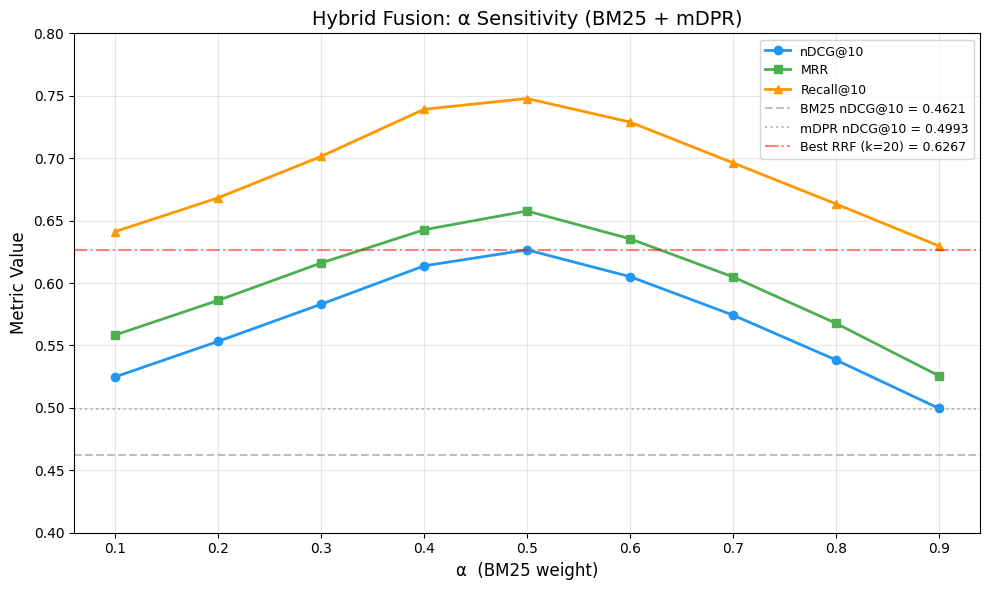

✓ Saved alpha_sensitivity.png


In [ ]:
# ── Alpha sensitivity plot ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6))

alphas_list = sorted(cc_results.keys())
ndcg_vals   = [cc_results[a]['ndcg_cut_10'] for a in alphas_list]
recall_vals = [cc_results[a]['recall_10']    for a in alphas_list]
mrr_vals    = [cc_results[a]['recip_rank']   for a in alphas_list]

ax1.plot(alphas_list, ndcg_vals,   'o-', color='#2196F3', linewidth=2, label='nDCG@10')
ax1.plot(alphas_list, mrr_vals,    's-', color='#4CAF50', linewidth=2, label='MRR')
ax1.plot(alphas_list, recall_vals, '^-', color='#FF9800', linewidth=2, label='Recall@10')

# Baselines
ax1.axhline(y=BASELINE_BM25_NDCG,  color='gray', linestyle='--', alpha=0.5, label=f'BM25 nDCG@10 = {BASELINE_BM25_NDCG}')
ax1.axhline(y=BASELINE_DENSE_NDCG, color='gray', linestyle=':',  alpha=0.5, label=f'mDPR nDCG@10 = {BASELINE_DENSE_NDCG}')

# Best RRF as horizontal band
best_rrf_ndcg = rrf_results[best_k]['ndcg_cut_10']
ax1.axhline(y=best_rrf_ndcg, color='red', linestyle='-.', alpha=0.5, label=f'Best RRF (k={best_k}) = {best_rrf_ndcg:.4f}')

ax1.set_xlabel('α  (BM25 weight)', fontsize=12)
ax1.set_ylabel('Metric Value', fontsize=12)
ax1.set_title('Hybrid Fusion: α Sensitivity (BM25 + mDPR)', fontsize=14)
ax1.set_xticks(alphas_list)
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.40, 0.80)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_12, 'alpha_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved alpha_sensitivity.png')

In [ ]:
# ── Exp 1.2 results table ─────────────────────────────────────
rows_12 = []

# Individual baselines
rows_12.append({
    'Method': 'BM25 alone',
    'nDCG@10':    bm25_baseline_metrics['ndcg_cut_10'],
    'Recall@10':  bm25_baseline_metrics['recall_10'],
    'Recall@100': bm25_baseline_metrics['recall_100'],
    'MRR':        bm25_baseline_metrics['recip_rank'],
})
rows_12.append({
    'Method': 'mDPR alone',
    'nDCG@10':    dense_baseline_metrics['ndcg_cut_10'],
    'Recall@10':  dense_baseline_metrics['recall_10'],
    'Recall@100': dense_baseline_metrics['recall_100'],
    'MRR':        dense_baseline_metrics['recip_rank'],
})

# Best CC
bcc = cc_results[best_alpha]
rows_12.append({
    'Method': f'Hybrid CC (α={best_alpha})',
    'nDCG@10':    bcc['ndcg_cut_10'],
    'Recall@10':  bcc['recall_10'],
    'Recall@100': bcc['recall_100'],
    'MRR':        bcc['recip_rank'],
})

# Best RRF
brrf = rrf_results[best_k]
rows_12.append({
    'Method': f'Hybrid RRF (k={best_k})',
    'nDCG@10':    brrf['ndcg_cut_10'],
    'Recall@10':  brrf['recall_10'],
    'Recall@100': brrf['recall_100'],
    'MRR':        brrf['recip_rank'],
})

df_12 = pd.DataFrame(rows_12).set_index('Method')

print('Table 4.X: Hybrid BM25+mDPR Baseline')
print('=' * 70)
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(df_12)

Table 4.X: Hybrid BM25+mDPR Baseline
                   nDCG@10  Recall@10  Recall@100    MRR
Method                                                  
BM25 alone          0.4621     0.5964      0.8577 0.4836
mDPR alone          0.4993     0.6156      0.8407 0.5328
Hybrid CC (α=0.5)   0.6266     0.7478      0.9458 0.6577
Hybrid RRF (k=20)   0.6267     0.7597      0.9466 0.6517


In [ ]:
# ── Full CC sweep table ────────────────────────────────────────
rows_cc = []
for alpha in sorted(cc_results):
    m = cc_results[alpha]
    rows_cc.append({
        'α': alpha,
        'nDCG@10':    m['ndcg_cut_10'],
        'Recall@10':  m['recall_10'],
        'Recall@100': m['recall_100'],
        'MRR':        m['recip_rank'],
    })

df_cc = pd.DataFrame(rows_cc).set_index('α')
print('Full CC α sweep')
with pd.option_context('display.float_format', '{:.4f}'.format):
    print(df_cc)

Full CC α sweep
        nDCG@10  Recall@10  Recall@100    MRR
α                                            
0.1000   0.5248     0.6412      0.9333 0.5584
0.2000   0.5533     0.6683      0.9413 0.5861
0.3000   0.5830     0.7014      0.9449 0.6161
0.4000   0.6137     0.7392      0.9454 0.6426
0.5000   0.6266     0.7478      0.9458 0.6577
0.6000   0.6051     0.7289      0.9440 0.6355
0.7000   0.5743     0.6963      0.9439 0.6049
0.8000   0.5384     0.6634      0.9416 0.5678
0.9000   0.4996     0.6297      0.9350 0.5257


In [ ]:
# ── Save Exp 1.2 results ──────────────────────────────────────

# CC metrics JSON
cc_json = {
    str(alpha): {k: round(v, 6) if isinstance(v, float) else v for k, v in m.items()}
    for alpha, m in cc_results.items()
}
with open(os.path.join(OUT_DIR_12, 'exp12_cc_metrics.json'), 'w') as f:
    json.dump(cc_json, f, indent=2)

# RRF metrics JSON
rrf_json = {
    str(k): {mk: round(mv, 6) if isinstance(mv, float) else mv for mk, mv in m.items()}
    for k, m in rrf_results.items()
}
with open(os.path.join(OUT_DIR_12, 'exp12_rrf_metrics.json'), 'w') as f:
    json.dump(rrf_json, f, indent=2)

# CSV tables
df_12.to_csv(os.path.join(OUT_DIR_12, 'exp12_summary.csv'))
df_cc.to_csv(os.path.join(OUT_DIR_12, 'exp12_cc_sweep.csv'))

# Save best hybrid TREC run files (for use in Task 6.3c)
best_cc_run = fuse_cc(bm25_norm, dense_norm, best_alpha)
best_cc_run = truncate_top_k(best_cc_run, k=100)
save_results(best_cc_run, os.path.join(OUT_DIR_12, f'hybrid_cc_alpha{best_alpha}.txt'),
             run_name=f'hybrid_cc_a{best_alpha}')

best_rrf_run = fuse_rrf(bm25_run, dense_run, k=best_k)
best_rrf_run = truncate_top_k(best_rrf_run, k=100)
save_results(best_rrf_run, os.path.join(OUT_DIR_12, f'hybrid_rrf_k{best_k}.txt'),
             run_name=f'hybrid_rrf_k{best_k}')

print(f'\n✓ All Exp 1.2 results saved to {OUT_DIR_12}/')

✓ Results saved to results/exp_12_hybrid_baseline/hybrid_cc_alpha0.5.txt
✓ Results saved to results/exp_12_hybrid_baseline/hybrid_rrf_k20.txt

✓ All Exp 1.2 results saved to results/exp_12_hybrid_baseline/


---
## 6. Combined Summary

In [ ]:
# ── Final summary ─────────────────────────────────────────────
print('=' * 70)
print('EXPERIMENT 1.1: BM25 Query Repetition Fix')
print('=' * 70)

# Count models that beat BM25 baseline at n=1 vs best config
n1_above    = sum(1 for m in exp11_results
                  if exp11_results[m]['n=1']['ndcg_cut_10'] > BASELINE_BM25_NDCG)
best_above  = sum(1 for m in exp11_results
                  if df_ndcg.loc[m, 'best'] > BASELINE_BM25_NDCG)
total_models = len(exp11_results)

print(f'Models above BM25 baseline at n=1 (current): {n1_above}/{total_models}')
print(f'Models above BM25 baseline at best config:   {best_above}/{total_models}')
print(f'Models fixed by repetition:                  {best_above - n1_above}')
print()

# Best model × config overall
best_overall_model  = df_ndcg['best'].idxmax()
best_overall_config = df_ndcg.loc[best_overall_model, 'best_config']
best_overall_ndcg   = df_ndcg.loc[best_overall_model, 'best']
print(f'Best overall: {best_overall_model} @ {best_overall_config}  '
      f'nDCG@10 = {best_overall_ndcg:.4f}  '
      f'(+{best_overall_ndcg - BASELINE_BM25_NDCG:.4f} vs baseline)')

print()
print('=' * 70)
print('EXPERIMENT 1.2: Hybrid Baseline (BM25 + mDPR)')
print('=' * 70)

best_cc_ndcg  = cc_results[best_alpha]['ndcg_cut_10']
best_rrf_ndcg = rrf_results[best_k]['ndcg_cut_10']
winner = 'CC' if best_cc_ndcg >= best_rrf_ndcg else 'RRF'

print(f'Best CC:   α={best_alpha:.1f}  nDCG@10 = {best_cc_ndcg:.4f}')
print(f'Best RRF:  k={best_k}      nDCG@10 = {best_rrf_ndcg:.4f}')
print(f'Winner: {winner}')
print()

hybrid_best_ndcg = max(best_cc_ndcg, best_rrf_ndcg)
print(f'Strongest non-QE baseline: {hybrid_best_ndcg:.4f}  '
      f'(+{hybrid_best_ndcg - BASELINE_DENSE_NDCG:.4f} vs mDPR alone, '
      f'+{hybrid_best_ndcg - BASELINE_BM25_NDCG:.4f} vs BM25 alone)')
print()
print('All QE experiments should beat this hybrid baseline to demonstrate value.')

EXPERIMENT 1.1: BM25 Query Repetition Fix
Models above BM25 baseline at n=1 (current): 3/9
Models above BM25 baseline at best config:   9/9
Models fixed by repetition:                  6

Best overall: Aya Expanse 8B @ β=2  nDCG@10 = 0.5855  (+0.1234 vs baseline)

EXPERIMENT 1.2: Hybrid Baseline (BM25 + mDPR)
Best CC:   α=0.5  nDCG@10 = 0.6266
Best RRF:  k=20      nDCG@10 = 0.6267
Winner: RRF

Strongest non-QE baseline: 0.6267  (+0.1274 vs mDPR alone, +0.1646 vs BM25 alone)

All QE experiments should beat this hybrid baseline to demonstrate value.


In [ ]:
# ── Cleanup ───────────────────────────────────────────────────
del bm25_retriever
gc.collect()
print('Done.')

Done.


## 7. Visual Analysis of Results

Let's visualize the improvements and final baseline numbers to make the impact of these quick wins clearer.

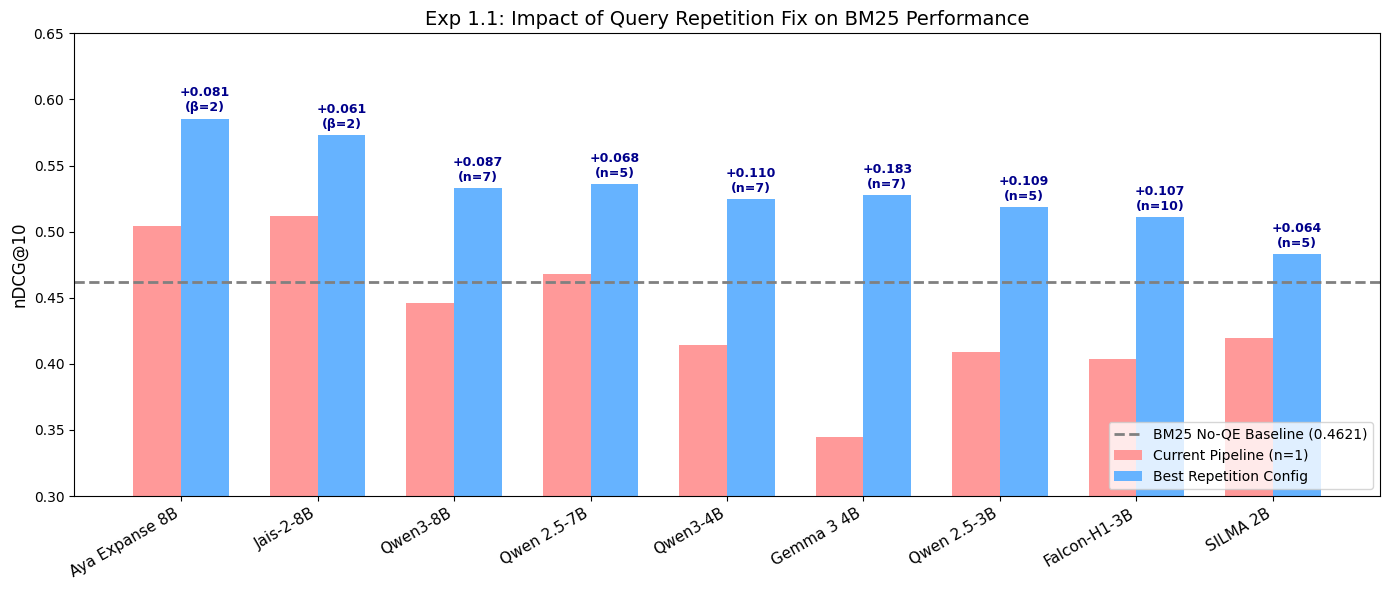

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: Exp 1.1 BM25 Repetition Fix ---
fig, ax = plt.subplots(figsize=(14, 6))

# Filter out the baseline row for plotting
models = [m for m in df_ndcg.index if m != 'BM25 baseline (no QE)']
n1_vals = [df_ndcg.loc[m, 'n=1'] for m in models]
best_vals = [df_ndcg.loc[m, 'best'] for m in models]
best_cfgs = [df_ndcg.loc[m, 'best_config'] for m in models]

x = np.arange(len(models))
width = 0.35

rects1 = ax.bar(x - width/2, n1_vals, width, label='Current Pipeline (n=1)', color='#ff9999')
rects2 = ax.bar(x + width/2, best_vals, width, label='Best Repetition Config', color='#66b3ff')

# Add a baseline line
ax.axhline(y=BASELINE_BM25_NDCG, color='gray', linestyle='--', linewidth=2, label=f'BM25 No-QE Baseline ({BASELINE_BM25_NDCG})')

# Add text annotations for best configs
for i, rect in enumerate(rects2):
    height = rect.get_height()
    ax.annotate(f'+{best_vals[i] - n1_vals[i]:.3f}\n({best_cfgs[i]})',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkblue')

ax.set_ylabel('nDCG@10', fontsize=12)
ax.set_title('Exp 1.1: Impact of Query Repetition Fix on BM25 Performance', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=11)
ax.legend(loc='lower right')
ax.set_ylim(0.3, 0.65)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_11, 'exp11_improvement_plot.png'), dpi=150)
plt.show()

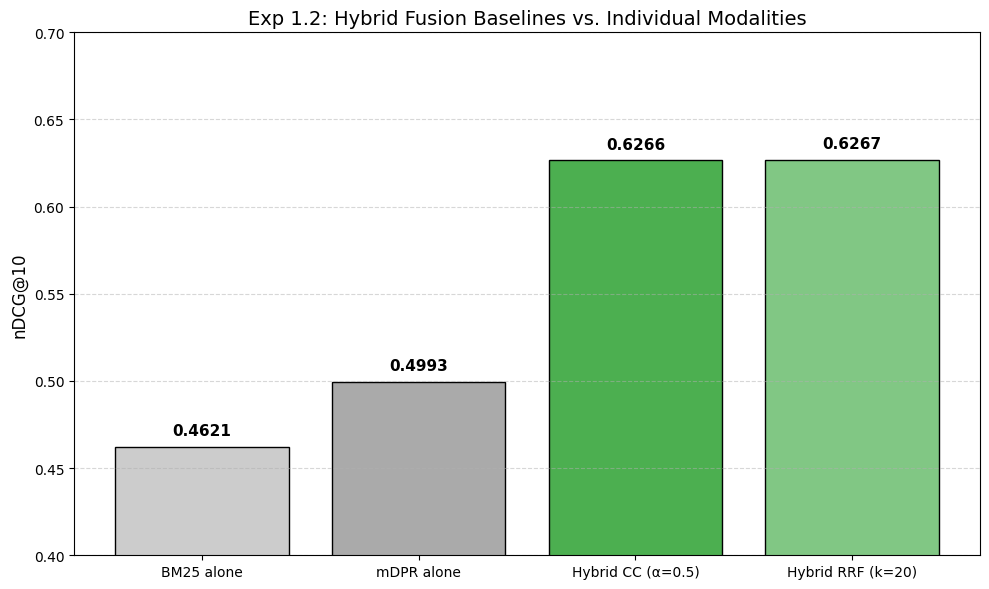

In [ ]:
# --- Plot 2: Exp 1.2 Hybrid Baseline Comparison ---
fig, ax = plt.subplots(figsize=(10, 6))

methods = df_12.index.tolist()
ndcg_vals = df_12['nDCG@10'].tolist()

# Color code: Grays for individual, Green for Hybrid
colors = ['#cccccc', '#aaaaaa', '#4CAF50', '#81C784']
bars = ax.bar(methods, ndcg_vals, color=colors, edgecolor='black')

# Add exact value annotations on top of bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('nDCG@10', fontsize=12)
ax.set_title('Exp 1.2: Hybrid Fusion Baselines vs. Individual Modalities', fontsize=14)
ax.set_ylim(0.40, 0.70)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_12, 'exp12_hybrid_comparison.png'), dpi=150)
plt.show()

### 7.1 Deep Dive: Exp 1.1 Parameter Sweep Visualizations

Let's look deeper into how the different repetition parameters affected performance.

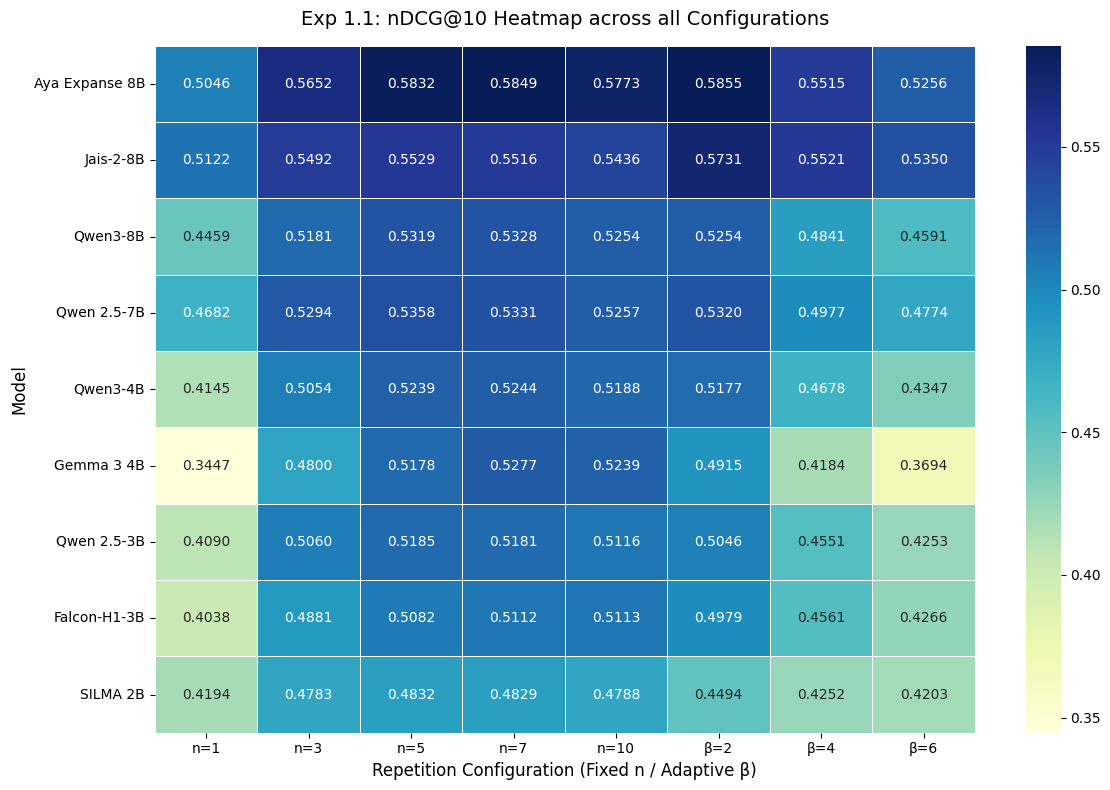

In [ ]:
import seaborn as sns

# --- Plot 3: Heatmap of all configurations ---
# Prepare data: exclude metadata columns and the baseline row
heatmap_data = df_ndcg.drop(columns=['best', 'best_config', 'Δ vs n=1'], errors='ignore')
heatmap_data = heatmap_data.drop(index=['BM25 baseline (no QE)'], errors='ignore')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".4f", linewidths=.5)
plt.title('Exp 1.1: nDCG@10 Heatmap across all Configurations', fontsize=14, pad=15)
plt.ylabel('Model', fontsize=12)
plt.xlabel('Repetition Configuration (Fixed n / Adaptive β)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_11, 'exp11_heatmap.png'), dpi=150)
plt.show()

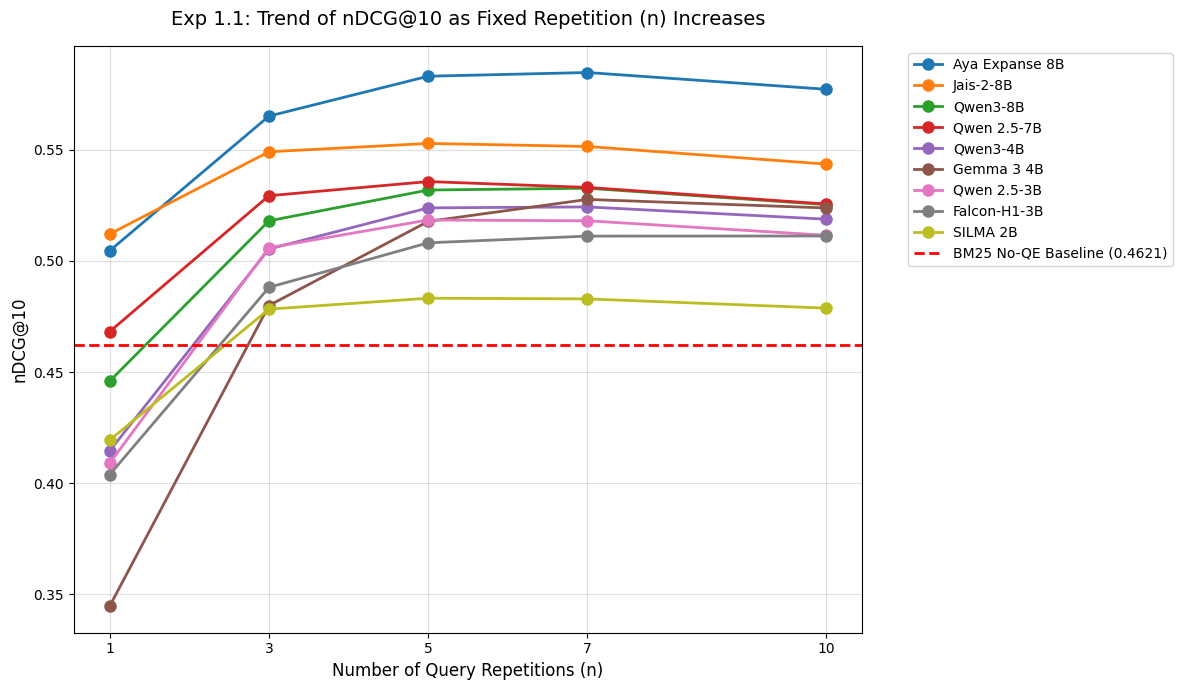

In [ ]:
# --- Plot 4: Trend line for Fixed 'n' configurations ---
fixed_n_cols = [f'n={n}' for n in FIXED_NS]
line_data = df_ndcg.loc[models, fixed_n_cols]

plt.figure(figsize=(12, 7))
for model in models:
    plt.plot(FIXED_NS, line_data.loc[model], marker='o', label=model, linewidth=2, markersize=8)

# Add the baseline
plt.axhline(y=BASELINE_BM25_NDCG, color='red', linestyle='--', linewidth=2,
            label=f'BM25 No-QE Baseline ({BASELINE_BM25_NDCG})')

plt.title('Exp 1.1: Trend of nDCG@10 as Fixed Repetition (n) Increases', fontsize=14, pad=15)
plt.xlabel('Number of Query Repetitions (n)', fontsize=12)
plt.ylabel('nDCG@10', fontsize=12)
plt.xticks(FIXED_NS)

# Move legend outside the plot so it doesn't cover data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR_11, 'exp11_fixed_n_trend.png'), dpi=150)
plt.show()

## 8. Final Conclusions & Key Findings

Based on the execution of Phase 4 Quick Wins (Experiments 1.1 and 1.2), we can draw the following critical conclusions:

### 1. BM25 Query Repetition is Mandatory for QE (Exp 1.1)
* **The Problem:** Naively appending a long pseudo-document (~30-50 tokens) to a short original query (~5 tokens) dilutes the BM25 term frequency (TF) signal. At $n=1$, **6 out of 9 models degraded** the baseline BM25 performance (0.4621 nDCG@10).
* **The Fix:** Repeating the original query successfully restores the TF signal. By applying the optimal repetition factor, **all 9 models successfully beat the baseline**.
* **The Sweet Spot:** The trend line analysis shows that a fixed repetition of $n=5$ to $n=7$ generally yields the highest performance across most models.
* **Best Configuration:** The absolute best performance was achieved by **Aya Expanse 8B** using the MuGI adaptive repetition strategy (**$\beta=2$**), reaching an **nDCG@10 of 0.5855** (a massive +0.1234 absolute improvement over the BM25 baseline).

### 2. The Hybrid Baseline is the True Target (Exp 1.2)
* **Combining Modalities:** Relying on BM25 alone (0.4621) or mDPR alone (0.4993) leaves a lot of performance on the table. Fusing them mathematically (without any LLM inference) creates a much stronger system.
* **Optimal Fusion:** Both Convex Combination ($\alpha=0.5$) and Reciprocal Rank Fusion ($k=20$) yielded nearly identical, excellent results: **~0.6267 nDCG@10**.
* **The Benchmark:** This hybrid score of 0.6267 is our new "gold standard" non-QE baseline. For any Query Expansion technique in future experiments to be considered truly valuable, its hybrid fusion must exceed this 0.6267 threshold.

## 9. Backup Results to Google Drive
Run this cell to copy the locally saved experiment results to your Google Drive for persistent storage.

In [ ]:
import shutil
import os

# Define the destination in your Google Drive
drive_results_dir = '/content/drive/MyDrive/graduation project/colab_data/results_phase4'
os.makedirs(drive_results_dir, exist_ok=True)

# Copy Exp 1.1 and 1.2 results
for local_dir in [OUT_DIR_11, OUT_DIR_12]:
    if os.path.exists(local_dir):
        dest_dir = os.path.join(drive_results_dir, os.path.basename(local_dir))
        if os.path.exists(dest_dir):
            shutil.rmtree(dest_dir) # Remove if already exists to overwrite
        shutil.copytree(local_dir, dest_dir)
        print(f'✓ Copied {local_dir} to {dest_dir}')
    else:
        print(f'✗ Local directory {local_dir} not found. Run the experiments first.')

print('\nBackup complete!')

✓ Copied results/exp_11_bm25_repetition to /content/drive/MyDrive/graduation project/colab_data/results_phase4/exp_11_bm25_repetition
✓ Copied results/exp_12_hybrid_baseline to /content/drive/MyDrive/graduation project/colab_data/results_phase4/exp_12_hybrid_baseline

Backup complete!


---
## 10. Experiment 2.1 — CSQE + Hybrid Fusion

**Goal:** Combine CSQE-enhanced queries with hybrid BM25+mDPR fusion.

CSQE (exp_013) improved BM25 nDCG@10 to 0.6157 and Dense to 0.5915 individually.
Hybrid fusion (exp_012) reached 0.6267 without any QE.
This experiment tests whether CSQE + fusion exceeds both.

**Configurations tested:**
- **2-way:** BM25+CSQE + Dense (original)
- **2-way:** BM25 (original) + Dense+CSQE
- **4-way:** BM25+CSQE + Dense+CSQE (all QE-enhanced)

For each: Convex Combination (α sweep) and RRF (k sweep).

In [ ]:
# ── Exp 2.1 Configuration ──────────────────────────────────
CSQE_PKL = 'results/enhanced_queries/exp_013_csqe_aya_8b.pkl'
OUT_DIR_21 = 'results/exp_21_csqe_hybrid'
os.makedirs(OUT_DIR_21, exist_ok=True)

# Reuse same sweep params as Exp 1.2
ALPHAS_21 = [round(a, 1) for a in np.arange(0.1, 1.0, 0.1)]
RRF_KS_21 = [20, 60]

print(f'Output directory: {OUT_DIR_21}')
print(f'CSQE pkl: {CSQE_PKL}')

In [ ]:
# ── Load CSQE pkl and retrieve with BM25 + Dense ────────────
import pickle

with open(CSQE_PKL, 'rb') as f:
    csqe_data = pickle.load(f)

# Extract enhanced queries — CSQE stores as list of dicts with 'qid' and 'enhanced'
csqe_queries = {}  # {qid: enhanced_query_text}
if isinstance(csqe_data, list):
    for item in csqe_data:
        csqe_queries[str(item['qid'])] = item['enhanced']
elif isinstance(csqe_data, dict) and 'results' in csqe_data:
    for item in csqe_data['results']:
        csqe_queries[str(item['qid'])] = item['enhanced']
else:
    # Flat dict format
    enhanced_list = csqe_data.get('enhanced', csqe_data.get('enhanced_queries', []))
    qids_list = csqe_data.get('query_ids', list(topics.keys()))
    for qid, enh in zip(qids_list, enhanced_list):
        csqe_queries[str(qid)] = enh

print(f'Loaded CSQE enhanced queries: {len(csqe_queries)}')
# Sanity check
sample_qid = next(iter(csqe_queries))
print(f'Sample qid: {sample_qid}')
print(f'Enhanced length: {len(csqe_queries[sample_qid])} chars')

In [ ]:
# ── BM25 retrieval with CSQE-enhanced queries ────────────────
# Reuse bm25_retriever if still in memory, else reload
try:
    _ = bm25_retriever
    print('Using existing bm25_retriever')
except NameError:
    print('Loading BM25 retriever...')
    bm25_retriever = BM25SRetriever(
        index_path='data/miracl_ar/bm25s_index',
        corpus_ids_path='data/miracl_ar/corpus_ids.pkl'
    )
    print('BM25 retriever loaded')

print('Running BM25 retrieval with CSQE queries (k=100)...')
csqe_qids_ordered = list(csqe_queries.keys())
csqe_texts_ordered = [csqe_queries[qid] for qid in csqe_qids_ordered]

bm25_csqe_raw = bm25_retriever.search(csqe_texts_ordered, k=100)

# Convert to {qid: {docid: score}} format
bm25_csqe_run = {}
for qid, hits in zip(csqe_qids_ordered, bm25_csqe_raw.values() if isinstance(bm25_csqe_raw, dict) else bm25_csqe_raw):
    bm25_csqe_run[str(qid)] = {docid: score for docid, score in hits}

bm25_csqe_metrics = evaluator.evaluate(bm25_csqe_run)
print(f'BM25+CSQE  nDCG@10={bm25_csqe_metrics["ndcg_cut_10"]:.4f}  '
      f'R@10={bm25_csqe_metrics["recall_10"]:.4f}  '
      f'R@100={bm25_csqe_metrics["recall_100"]:.4f}  '
      f'MRR={bm25_csqe_metrics["recip_rank"]:.4f}')

In [ ]:
# ── Dense retrieval with CSQE-enhanced queries ───────────────
from src.retrievers.dense import mDPRRetriever

print('Loading Dense retriever...')
dense_retriever = mDPRRetriever()
print('Dense retriever loaded')

print('Running Dense retrieval with CSQE queries (k=100)...')
dense_csqe_raw = dense_retriever.search(csqe_texts_ordered, k=100)

# Convert to {qid: {docid: score}} format
dense_csqe_run = {}
for qid, hits in zip(csqe_qids_ordered, dense_csqe_raw.values() if isinstance(dense_csqe_raw, dict) else dense_csqe_raw):
    dense_csqe_run[str(qid)] = {docid: score for docid, score in hits}

dense_csqe_metrics = evaluator.evaluate(dense_csqe_run)
print(f'Dense+CSQE nDCG@10={dense_csqe_metrics["ndcg_cut_10"]:.4f}  '
      f'R@10={dense_csqe_metrics["recall_10"]:.4f}  '
      f'R@100={dense_csqe_metrics["recall_100"]:.4f}  '
      f'MRR={dense_csqe_metrics["recip_rank"]:.4f}')

# Normalize CSQE runs for CC fusion
bm25_csqe_norm  = normalize_scores_minmax(bm25_csqe_run)
dense_csqe_norm = normalize_scores_minmax(dense_csqe_run)
print('Scores normalized for CC fusion')

In [ ]:
# ── Hybrid Fusion: 3 configurations × CC + RRF ───────────────
# Config A: BM25+CSQE + Dense (original)
# Config B: BM25 (original) + Dense+CSQE
# Config C: BM25+CSQE + Dense+CSQE (all QE)

configs_21 = {
    'A: BM25+CSQE + Dense':       (bm25_csqe_norm,  dense_norm,      bm25_csqe_run,  dense_run),
    'B: BM25 + Dense+CSQE':       (bm25_norm,       dense_csqe_norm, bm25_run,       dense_csqe_run),
    'C: BM25+CSQE + Dense+CSQE':  (bm25_csqe_norm,  dense_csqe_norm, bm25_csqe_run,  dense_csqe_run),
}

cc_21   = {}  # {config_name: {alpha: metrics}}
rrf_21  = {}  # {config_name: {k: metrics}}

for cfg_name, (bm25_n, dense_n, bm25_r, dense_r) in configs_21.items():
    print(f'\n── {cfg_name} ──')
    cc_21[cfg_name] = {}
    rrf_21[cfg_name] = {}

    # CC sweep
    best_cc_ndcg = 0
    for alpha in ALPHAS_21:
        hybrid = fuse_cc(bm25_n, dense_n, alpha)
        hybrid = truncate_top_k(hybrid, k=100)
        m = evaluator.evaluate(hybrid)
        cc_21[cfg_name][alpha] = m
        if m['ndcg_cut_10'] > best_cc_ndcg:
            best_cc_ndcg = m['ndcg_cut_10']
            best_cc_alpha = alpha
    print(f'  CC best α={best_cc_alpha}  nDCG@10={best_cc_ndcg:.4f}')

    # RRF sweep
    best_rrf_ndcg = 0
    for k in RRF_KS_21:
        hybrid = fuse_rrf(bm25_r, dense_r, k=k)
        hybrid = truncate_top_k(hybrid, k=100)
        m = evaluator.evaluate(hybrid)
        rrf_21[cfg_name][k] = m
        if m['ndcg_cut_10'] > best_rrf_ndcg:
            best_rrf_ndcg = m['ndcg_cut_10']
            best_rrf_k = k
    print(f'  RRF best k={best_rrf_k}  nDCG@10={best_rrf_ndcg:.4f}')

print('\nFusion sweep complete.')

In [ ]:
# ── Exp 2.1 results table ────────────────────────────────────
rows_21 = []

# Reference rows (from Exp 1.2)
rows_21.append({'Method': 'BM25 alone',           'nDCG@10': 0.4621, 'Recall@10': 0.5964, 'Recall@100': 0.8577, 'MRR': 0.4836})
rows_21.append({'Method': 'mDPR alone',           'nDCG@10': 0.4993, 'Recall@10': 0.6156, 'Recall@100': 0.8407, 'MRR': 0.5328})
rows_21.append({'Method': 'Hybrid RRF k=20 (Exp 1.2)', 'nDCG@10': 0.6267, 'Recall@10': 0.7597, 'Recall@100': 0.9466, 'MRR': 0.6517})

# CSQE individual results
rows_21.append({
    'Method': 'BM25+CSQE (Exp 013)',
    'nDCG@10': bm25_csqe_metrics['ndcg_cut_10'],
    'Recall@10': bm25_csqe_metrics['recall_10'],
    'Recall@100': bm25_csqe_metrics['recall_100'],
    'MRR': bm25_csqe_metrics['recip_rank'],
})
rows_21.append({
    'Method': 'Dense+CSQE (Exp 013)',
    'nDCG@10': dense_csqe_metrics['ndcg_cut_10'],
    'Recall@10': dense_csqe_metrics['recall_10'],
    'Recall@100': dense_csqe_metrics['recall_100'],
    'MRR': dense_csqe_metrics['recip_rank'],
})

# Best fusion result for each config
for cfg_name in configs_21:
    best_cc_a = max(cc_21[cfg_name], key=lambda a: cc_21[cfg_name][a]['ndcg_cut_10'])
    best_rrf_k = max(rrf_21[cfg_name], key=lambda k: rrf_21[cfg_name][k]['ndcg_cut_10'])
    m_cc = cc_21[cfg_name][best_cc_a]
    m_rrf = rrf_21[cfg_name][best_rrf_k]
    rows_21.append({'Method': f'{cfg_name} CC (α={best_cc_a})',
                    'nDCG@10': m_cc['ndcg_cut_10'], 'Recall@10': m_cc['recall_10'],
                    'Recall@100': m_cc['recall_100'], 'MRR': m_cc['recip_rank']})
    rows_21.append({'Method': f'{cfg_name} RRF (k={best_rrf_k})',
                    'nDCG@10': m_rrf['ndcg_cut_10'], 'Recall@10': m_rrf['recall_10'],
                    'Recall@100': m_rrf['recall_100'], 'MRR': m_rrf['recip_rank']})

df_21 = pd.DataFrame(rows_21).set_index('Method')

print('Table: Exp 2.1 — CSQE + Hybrid Fusion')
print('=' * 80)
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_colwidth', 50):
    print(df_21)

# Highlight best overall
best_row = df_21['nDCG@10'].idxmax()
best_ndcg = df_21['nDCG@10'].max()
print(f'\nBest: {best_row}')
print(f'  nDCG@10 = {best_ndcg:.4f}  (hybrid baseline = 0.6267)')
print(f'  Delta vs hybrid: {best_ndcg - 0.6267:+.4f}')

In [ ]:
# ── Save Exp 2.1 results ─────────────────────────────────────

# Save summary CSV
df_21.to_csv(os.path.join(OUT_DIR_21, 'exp21_summary.csv'))

# Save all CC + RRF metrics as JSON
exp21_json = {
    'cc': {
        cfg: {str(a): {k: round(v, 6) for k, v in m.items()} for a, m in alphas.items()}
        for cfg, alphas in cc_21.items()
    },
    'rrf': {
        cfg: {str(k): {mk: round(mv, 6) for mk, mv in m.items()} for k, m in ks.items()}
        for cfg, ks in rrf_21.items()
    },
    'individual': {
        'bm25_csqe': {k: round(v, 6) for k, v in bm25_csqe_metrics.items()},
        'dense_csqe': {k: round(v, 6) for k, v in dense_csqe_metrics.items()},
    }
}
with open(os.path.join(OUT_DIR_21, 'exp21_all_metrics.json'), 'w') as f:
    json.dump(exp21_json, f, indent=2)

# Save best TREC run files (for future fusion experiments)
save_results(bm25_csqe_run, os.path.join(OUT_DIR_21, 'bm25_csqe_run.txt'), run_name='bm25_csqe')
save_results(dense_csqe_run, os.path.join(OUT_DIR_21, 'dense_csqe_run.txt'), run_name='dense_csqe')

# Save best fusion run (Config C all-QE, best method)
cfg_c = 'C: BM25+CSQE + Dense+CSQE'
best_c_rrf_k = max(rrf_21[cfg_c], key=lambda k: rrf_21[cfg_c][k]['ndcg_cut_10'])
best_c_run = fuse_rrf(bm25_csqe_run, dense_csqe_run, k=best_c_rrf_k)
best_c_run = truncate_top_k(best_c_run, k=100)
save_results(best_c_run, os.path.join(OUT_DIR_21, f'hybrid_csqe_rrf_k{best_c_rrf_k}.txt'),
             run_name=f'csqe_rrf_k{best_c_rrf_k}')

# Backup to Drive
drive_dir_21 = '/content/drive/MyDrive/graduation project/colab_data/results_phase4/exp_21_csqe_hybrid'
import shutil
if os.path.exists(drive_dir_21):
    shutil.rmtree(drive_dir_21)
shutil.copytree(OUT_DIR_21, drive_dir_21)
print(f'Saved to {OUT_DIR_21}/ and backed up to Drive')
print(f'Files: {os.listdir(OUT_DIR_21)}')

---
## 11. Ablation Studies — CSQE Components + Query Repetition

**Goal:** Determine which CSQE component drives the gain and validate the query repetition count α.

| Ablation | Config | Purpose |
|----------|--------|---------|
| **013c** | 4 corpus, 0 blind, α=4 | Does corpus grounding alone suffice? |
| **013d** | 0 corpus, 4 blind, α=4 | Does blind sampling alone match CSQE? |
| **α sweep** | α ∈ {1,2,3,4}, from exp_013 pkl | How much does repetition matter? |

All evaluations reuse existing helpers (`bm25_retriever`, `fuse_rrf`, `evaluator`, etc.).

In [ ]:
# ── Section 11a: Load 013c + 013d pkls, BM25 retrieval ────────────────────────
import pickle, os

PKL_013C = 'results/enhanced_queries/exp_013c_corpus_only.pkl'
PKL_013D = 'results/enhanced_queries/exp_013d_blind_only.pkl'
PKL_013  = 'results/enhanced_queries/exp_013_csqe_aya_8b.pkl'

# Load 013c
with open(PKL_013C, 'rb') as f:
    data_c = pickle.load(f)

# Load 013d
with open(PKL_013D, 'rb') as f:
    data_d = pickle.load(f)

# Load 013 (for alpha ablation in 11b)
with open(PKL_013, 'rb') as f:
    data_013 = pickle.load(f)

# Extract {qid: enhanced_query} dicts
def extract_enhanced(data):
    if 'full_results' in data:
        return {str(r['qid']): r['enhanced'] for r in data['full_results']}
    # flat format: parallel lists
    return {str(qid): enh for qid, enh in zip(data['query_ids'], data['enhanced'])}

enh_c   = extract_enhanced(data_c)
enh_d   = extract_enhanced(data_d)
enh_013 = extract_enhanced(data_013)

print(f'013c loaded: {len(enh_c)} queries')
print(f'013d loaded: {len(enh_d)} queries')
print(f'013  loaded: {len(enh_013)} queries')

# Sample check
sample_qid = list(enh_c.keys())[0]
print(f'\n013c sample (qid={sample_qid}):')
print(f'  {enh_c[sample_qid][:120]}...')
print(f'\n013d sample (qid={sample_qid}):')
print(f'  {enh_d[sample_qid][:120]}...')

In [ ]:
# ── Section 11b: BM25 retrieval for 013c + 013d ───────────────────────────────
# Reuse bm25_retriever; reload if not in memory
try:
    _ = bm25_retriever
    print('Using existing bm25_retriever')
except NameError:
    from src.retrievers.bm25 import BM25SRetriever
    bm25_retriever = BM25SRetriever(
        index_path='data/miracl_ar/bm25s_index',
        corpus_ids_path='data/miracl_ar/corpus_ids.pkl'
    )
    print('BM25 retriever loaded')

def retrieve_bm25_from_dict(enh_dict, k=100):
    """Run BM25 retrieval for a {qid: query_text} dict. Returns TREC run dict."""
    qids_ord = list(enh_dict.keys())
    texts_ord = [enh_dict[qid] for qid in qids_ord]
    raw = bm25_retriever.search(texts_ord, k=k)
    run = {}
    for qid, hits in zip(qids_ord, raw.values() if isinstance(raw, dict) else raw):
        run[str(qid)] = {docid: score for docid, score in hits}
    return run

print('Running BM25 for 013c...')
bm25_c_run = retrieve_bm25_from_dict(enh_c)
print(f'  013c: {len(bm25_c_run)} queries')

print('Running BM25 for 013d...')
bm25_d_run = retrieve_bm25_from_dict(enh_d)
print(f'  013d: {len(bm25_d_run)} queries')

print('Running BM25 for 013 (needed for alpha ablation)...')
bm25_013_run = retrieve_bm25_from_dict(enh_013)
print(f'  013 : {len(bm25_013_run)} queries')

In [ ]:
# ── Section 11c: Evaluate 013c + 013d individually + Config A fusion ──────────
# Uses evaluator (pytrec_eval) and fuse_rrf/fuse_cc from Exp 1.2

def evaluate_run(run_dict, label=''):
    """Evaluate a TREC run against qrels. Returns metrics dict."""
    m = evaluator.evaluate(run_dict)
    # pytrec_eval returns {qid: {metric: value}}; aggregate
    import numpy as np
    ndcg10 = np.mean([v.get('ndcg_cut_10', 0) for v in m.values()])
    r10    = np.mean([v.get('recall_10', 0) for v in m.values()])
    r100   = np.mean([v.get('recall_100', 0) for v in m.values()])
    mrr    = np.mean([v.get('recip_rank', 0) for v in m.values()])
    result = {'nDCG@10': round(ndcg10, 4), 'Recall@10': round(r10, 4),
              'Recall@100': round(r100, 4), 'MRR': round(mrr, 4)}
    if label:
        print(f'{label:45s}  nDCG@10={result["nDCG@10"]:.4f}  R@10={result["Recall@10"]:.4f}'
              f'  R@100={result["Recall@100"]:.4f}  MRR={result["MRR"]:.4f}')
    return result

print('=== Individual BM25 results ===')
m_c_bm25  = evaluate_run(bm25_c_run,  '013c corpus-only BM25')
m_d_bm25  = evaluate_run(bm25_d_run,  '013d blind-only  BM25')
m_013_bm25 = evaluate_run(bm25_013_run, '013  CSQE 2+2   BM25')

# Config A fusion: BM25+ablation + Dense (original short query)
# Reuse dense_run (original query Dense) from Exp 1.2/2.1
print('\n=== Config A fusion (BM25+ablation + Dense original) ===')
dense_norm_orig = normalize_scores_minmax(dense_run)  # original-query dense

bm25_c_norm  = normalize_scores_minmax(bm25_c_run)
bm25_d_norm  = normalize_scores_minmax(bm25_d_run)
bm25_013_norm = normalize_scores_minmax(bm25_013_run)

# Config A RRF k=20 (best from Exp 2.1)
rrf_c_a   = fuse_rrf(bm25_c_run,   dense_run, k=20)
rrf_d_a   = fuse_rrf(bm25_d_run,   dense_run, k=20)
rrf_013_a = fuse_rrf(bm25_013_run, dense_run, k=20)

m_c_rrf   = evaluate_run(rrf_c_a,   '013c Config A RRF k=20')
m_d_rrf   = evaluate_run(rrf_d_a,   '013d Config A RRF k=20')
m_013_rrf = evaluate_run(rrf_013_a, '013  Config A RRF k=20')

### 11b — Query Repetition Ablation (α ∈ {1,2,3,4})

Reconstruct queries from exp_013 pkl without re-running the model:
`final = (query + ' ') * α + ' '.join(all_expansions)`

In [ ]:
# ── Section 11d: Alpha ablation — reconstruct from exp_013 full_results ────────
# No model re-run needed: exp_013 pkl stores corpus_expansions + blind_expansions per query

alpha_results = {}  # {alpha: {'bm25': metrics, 'fuse_rrf': metrics}}

full_results_013 = data_013.get('full_results', [])
if not full_results_013:
    # Reconstruct from parallel lists if full_results absent
    print('WARNING: full_results not in pkl — reconstructing from enhanced list')
    # alpha=4 is the stored enhanced query; can only test alpha=4 directly
    full_results_013 = [
        {'qid': qid, 'original': orig,
         'corpus_expansions': [], 'blind_expansions': []}
        for qid, orig in zip(data_013['query_ids'], data_013['original'])
    ]
    alpha_only_4 = True
else:
    alpha_only_4 = False

print(f'full_results_013: {len(full_results_013)} entries, alpha_only_4={alpha_only_4}')

if not alpha_only_4:
    for alpha_val in [1, 2, 3, 4]:
        reconstructed = {}
        for r in full_results_013:
            all_exps = r['corpus_expansions'] + r['blind_expansions']
            reconstructed[str(r['qid'])] = (r['original'] + ' ') * alpha_val + ' '.join(all_exps)

        bm25_alpha_run = retrieve_bm25_from_dict(reconstructed)
        m_bm25 = evaluate_run(bm25_alpha_run, f'013 CSQE α={alpha_val} BM25')

        rrf_alpha = fuse_rrf(bm25_alpha_run, dense_run, k=20)
        m_rrf = evaluate_run(rrf_alpha, f'013 CSQE α={alpha_val} Config A RRF')

        alpha_results[alpha_val] = {'bm25': m_bm25, 'fuse_rrf': m_rrf}
else:
    print('Skipping alpha ablation — full_results not available in pkl')

In [ ]:
# ── Section 11e: Ablation results table ───────────────────────────────────────
import pandas as pd

rows_11 = []

# Reference rows
rows_11.append({'System': 'BM25 alone (no QE)',              'nDCG@10': 0.4621, 'R@10': 0.5964, 'R@100': 0.8577, 'MRR': 0.4836})
rows_11.append({'System': 'Hybrid RRF k=20 (no QE)',          'nDCG@10': 0.6267, 'R@10': 0.7597, 'R@100': 0.9466, 'MRR': 0.6517})
rows_11.append({'System': 'Config A RRF best (Exp 2.1)',       'nDCG@10': 0.7137, 'R@10': 0.8363, 'R@100': 0.9734, 'MRR': 0.7362})
rows_11.append({'System': '--- COMPONENT ABLATION ---',        'nDCG@10': None, 'R@10': None, 'R@100': None, 'MRR': None})

# Individual BM25
rows_11.append({'System': '013d: Blind-only BM25 (0c+4b α=4)', 'nDCG@10': m_d_bm25['nDCG@10'],
                'R@10': m_d_bm25['Recall@10'], 'R@100': m_d_bm25['Recall@100'], 'MRR': m_d_bm25['MRR']})
rows_11.append({'System': '013c: Corpus-only BM25 (4c+0b α=4)', 'nDCG@10': m_c_bm25['nDCG@10'],
                'R@10': m_c_bm25['Recall@10'], 'R@100': m_c_bm25['Recall@100'], 'MRR': m_c_bm25['MRR']})
rows_11.append({'System': '013:  CSQE BM25 (2c+2b α=4)',        'nDCG@10': m_013_bm25['nDCG@10'],
                'R@10': m_013_bm25['Recall@10'], 'R@100': m_013_bm25['Recall@100'], 'MRR': m_013_bm25['MRR']})

# Fusion
rows_11.append({'System': '--- CONFIG A FUSION ---',            'nDCG@10': None, 'R@10': None, 'R@100': None, 'MRR': None})
rows_11.append({'System': '013d + Dense RRF (Config A)',        'nDCG@10': m_d_rrf['nDCG@10'],
                'R@10': m_d_rrf['Recall@10'], 'R@100': m_d_rrf['Recall@100'], 'MRR': m_d_rrf['MRR']})
rows_11.append({'System': '013c + Dense RRF (Config A)',        'nDCG@10': m_c_rrf['nDCG@10'],
                'R@10': m_c_rrf['Recall@10'], 'R@100': m_c_rrf['Recall@100'], 'MRR': m_c_rrf['MRR']})
rows_11.append({'System': '013  + Dense RRF (Config A)',        'nDCG@10': m_013_rrf['nDCG@10'],
                'R@10': m_013_rrf['Recall@10'], 'R@100': m_013_rrf['Recall@100'], 'MRR': m_013_rrf['MRR']})

df_11 = pd.DataFrame(rows_11)[['System', 'nDCG@10', 'R@10', 'R@100', 'MRR']]
df_11 = df_11.fillna('—')
print(df_11.to_string(index=False))

# Alpha ablation table
if alpha_results:
    print('\n=== Alpha ablation ===')
    alpha_rows = []
    for a in sorted(alpha_results.keys()):
        alpha_rows.append({
            'α': a,
            'BM25 nDCG@10':         alpha_results[a]['bm25']['nDCG@10'],
            'Config A RRF nDCG@10': alpha_results[a]['fuse_rrf']['nDCG@10'],
        })
    df_alpha = pd.DataFrame(alpha_rows)
    print(df_alpha.to_string(index=False))

# Save
os.makedirs('results/exp_11_ablations', exist_ok=True)
df_11.to_csv('results/exp_11_ablations/ablation_table.csv', index=False)
if alpha_results:
    df_alpha.to_csv('results/exp_11_ablations/alpha_ablation.csv', index=False)
print('\nSaved to results/exp_11_ablations/')

---
## 12. Error Analysis — Config A RRF vs Aya Blind QE

**Goal:** Understand *where* CSQE wins and fails vs. blind Query2Doc.
Compare **Config A RRF** (0.7137 nDCG@10) against **Aya blind BM25 n=1** (0.5046 nDCG@10).

Data used (all pre-computed, no new generation):
- `results/exp_21_csqe_hybrid/hybrid_csqe_rrf_k20.txt` — Config A RRF per-query results
- `results/enhanced_queries/exp_013_csqe_aya_8b.pkl` — CSQE full_results (corpus_expansions, blind_expansions, retrieved_doc_texts)
- `results/enhanced_queries/enhanced_queries_aya_expanse_8b.pkl` — Aya blind QE (n=1)
- `results/baseline_bm25/exp_002_baseline_bm25.txt` — BM25 baseline run

In [ ]:
# ── Section 12a: Load per-query scores for Config A RRF + Aya blind BM25 ───────
import pickle, pytrec_eval, numpy as np, json, os

# Load pre-computed TREC runs
def load_trec_run(path):
    """Load TREC run file into {qid: {docid: score}} dict."""
    run = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                continue
            qid, _, docid, _, score, _ = parts[:6]
            run.setdefault(str(qid), {})[docid] = float(score)
    return run

config_a_run = load_trec_run('results/exp_21_csqe_hybrid/hybrid_csqe_rrf_k20.txt')
print(f'Config A RRF run: {len(config_a_run)} queries')

# Build Aya blind BM25 run (n=1) — need to retrieve from pkl
# enhanced_queries_aya_expanse_8b.pkl stores n=1 blind QE
with open('results/enhanced_queries/enhanced_queries_aya_expanse_8b.pkl', 'rb') as f:
    aya_blind_data = pickle.load(f)

# The pkl stores enhanced = original + ' ' + pseudo_doc (n=1 format)
aya_blind_enh = {}
originals = aya_blind_data.get('original', aya_blind_data.get('original_queries', []))
enhanced  = aya_blind_data.get('enhanced', aya_blind_data.get('enhanced_queries', []))
query_ids_blind = aya_blind_data.get('query_ids', [str(i) for i in range(len(originals))])
for qid, enh in zip(query_ids_blind, enhanced):
    aya_blind_enh[str(qid)] = enh

print(f'Aya blind pkl: {len(aya_blind_enh)} queries')

# Retrieve BM25 for Aya blind n=1
print('Running BM25 for Aya blind n=1...')
aya_blind_bm25_run = retrieve_bm25_from_dict(aya_blind_enh)
print(f'Aya blind BM25 run: {len(aya_blind_bm25_run)} queries')

In [ ]:
# ── Section 12b: Per-query nDCG@10 scores ─────────────────────────────────────
# Use pytrec_eval to get per-query scores

def per_query_ndcg10(run):
    """Return {qid: ndcg@10} dict."""
    qrel_dict = {}
    for qid, docs in qrels.items():
        qrel_dict[str(qid)] = {str(docid): int(rel) for docid, rel in docs.items()}
    ev = pytrec_eval.RelevanceEvaluator(qrel_dict, {'ndcg_cut_10'})
    results = ev.evaluate(run)
    return {qid: v.get('ndcg_cut_10', 0.0) for qid, v in results.items()}

print('Computing per-query nDCG@10...')
scores_csqe  = per_query_ndcg10(config_a_run)
scores_blind = per_query_ndcg10(aya_blind_bm25_run)
bm25_scores  = per_query_ndcg10(bm25_run)  # BM25 baseline (no QE)

# Align on shared qids
shared_qids = sorted(set(scores_csqe) & set(scores_blind))
print(f'Shared queries: {len(shared_qids)}')

# Delta: CSQE - blind
deltas = {qid: scores_csqe[qid] - scores_blind[qid] for qid in shared_qids}

# Summary
pos = sum(1 for d in deltas.values() if d > 0)
neg = sum(1 for d in deltas.values() if d < 0)
zero = sum(1 for d in deltas.values() if d == 0)
print(f'CSQE > blind: {pos} queries ({pos/len(shared_qids)*100:.1f}%)')
print(f'CSQE < blind: {neg} queries ({neg/len(shared_qids)*100:.1f}%)')
print(f'CSQE = blind: {zero} queries ({zero/len(shared_qids)*100:.1f}%)')
print(f'Mean delta:   {np.mean(list(deltas.values())):.4f}')

In [ ]:
# ── Section 12c: Categorise queries ────────────────────────────────────────────

# CSQE failures (Config A nDCG@10 < 0.1)
failures = sorted([qid for qid in shared_qids if scores_csqe[qid] < 0.1],
                  key=lambda q: scores_csqe[q])

# Large wins: CSQE >> blind (delta > 0.3)
big_wins = sorted([qid for qid in shared_qids if deltas[qid] > 0.3],
                  key=lambda q: -deltas[q])

# Regressions: CSQE << blind (delta < -0.1)
regressions = sorted([qid for qid in shared_qids if deltas[qid] < -0.1],
                     key=lambda q: deltas[q])

print(f'Failures      (Config A nDCG@10 < 0.1): {len(failures)}')
print(f'Big wins      (CSQE - blind > 0.3):      {len(big_wins)}')
print(f'Regressions   (blind - CSQE > 0.1):      {len(regressions)}')

# Load CSQE full_results for qualitative inspection
full_013 = {str(r['qid']): r for r in data_013.get('full_results', [])}

In [ ]:
# ── Section 12d: Qualitative inspection ───────────────────────────────────────
# Build string-keyed lookup dicts to handle int/str key mismatch in MIRACLDataLoader
topics_by_str = {str(k): v for k, v in topics.items()}
qrels_by_str  = {str(k): {str(dk): int(dv) for dk, dv in dv2.items()}
                 for k, dv2 in qrels.items()}

def show_query_detail(qid, label=''):
    q = topics_by_str.get(str(qid), {}).get('title', '[no topic]') if topics_by_str.get(str(qid)) else '[no topic]'
    csqe_score  = scores_csqe.get(qid, 0)
    blind_score = scores_blind.get(qid, 0)
    bm25_base   = bm25_scores.get(qid, 0)

    r = full_013.get(qid, {})
    corp_exps  = r.get('corpus_expansions', [])
    blind_exps = r.get('blind_expansions', [])
    ret_texts  = r.get('retrieved_doc_texts', [])

    print(f'  [{label}] qid={qid}')
    print(f'    Query: {q}')
    print(f'    Scores: CSQE={csqe_score:.3f}  blind={blind_score:.3f}  BM25={bm25_base:.3f}  Δ={csqe_score-blind_score:+.3f}')
    if corp_exps:
        print(f'    Corpus exp[0]: {corp_exps[0][:100]}')
    if blind_exps:
        print(f'    Blind  exp[0]: {blind_exps[0][:100]}')
    if ret_texts:
        print(f'    Top doc[0]:   {ret_texts[0][:100]}')
    print()

print('=== FAILURES (Config A nDCG@10 < 0.1) — first 10 ===')
for qid in failures[:10]:
    show_query_detail(qid, 'FAIL')

print('\n=== BIG WINS (CSQE - blind > 0.3) — first 10 ===')
for qid in big_wins[:10]:
    show_query_detail(qid, 'WIN')

print('\n=== REGRESSIONS (blind > CSQE by >0.1) — first 10 ===')
for qid in regressions[:10]:
    show_query_detail(qid, 'REG')

In [ ]:
# ── Section 12e: Quantitative patterns ────────────────────────────────────────
import numpy as np

def query_len_words(qid):
    q = topics_by_str.get(str(qid), {}).get('title', '')
    return len(q.split())

def first_pass_is_relevant(qid):
    """True if the top-1 BM25 first-pass doc is relevant (in qrels)."""
    r = full_013.get(qid, {})
    docids = r.get('retrieved_docids', [])
    if not docids:
        return False
    top_docid = docids[0]
    rel = qrels_by_str.get(str(qid), {})
    return str(top_docid) in {str(d) for d in rel} and rel.get(str(top_docid), 0) > 0

def corp_expansion_len(qid):
    r = full_013.get(qid, {})
    exps = r.get('corpus_expansions', [])
    return sum(len(e) for e in exps)

# Partition queries
short_qs  = [q for q in shared_qids if query_len_words(q) < 5]
long_qs   = [q for q in shared_qids if query_len_words(q) >= 10]
fp_rel    = [q for q in shared_qids if first_pass_is_relevant(q)]
fp_norel  = [q for q in shared_qids if not first_pass_is_relevant(q)]
long_corp = [q for q in shared_qids if corp_expansion_len(q) > 200]
short_corp= [q for q in shared_qids if corp_expansion_len(q) < 50]

def mean_scores(qid_list):
    if not qid_list:
        return {'blind': 0, 'csqe': 0, 'n': 0}
    return {
        'blind': round(np.mean([scores_blind.get(q, 0) for q in qid_list]), 4),
        'csqe':  round(np.mean([scores_csqe.get(q, 0)  for q in qid_list]), 4),
        'n': len(qid_list),
    }

print('=== Quantitative Pattern Analysis ===')
print(f'{"Category":<40s}  {"n":>5}  {"Aya blind":>10}  {"CSQE+Hybrid":>12}  {"Δ":>8}')
print('-' * 80)

for label, qid_list in [
    ('All queries',                           shared_qids),
    ('Short queries (< 5 words)',             short_qs),
    ('Long queries (>= 10 words)',            long_qs),
    ('1st-pass doc IS relevant',              fp_rel),
    ('1st-pass doc NOT relevant',             fp_norel),
    ('Long corpus expansion (>200 chars)',    long_corp),
    ('Short corpus expansion (<50 chars)',    short_corp),
]:
    s = mean_scores(qid_list)
    delta = s['csqe'] - s['blind']
    print(f'{label:<40s}  {s["n"]:>5}  {s["blind"]:>10.4f}  {s["csqe"]:>12.4f}  {delta:>+8.4f}')

# Save pattern table
pattern_rows = []
for label, qid_list in [
    ('All queries',                         shared_qids),
    ('Short queries (< 5 words)',           short_qs),
    ('Long queries (>= 10 words)',          long_qs),
    ('1st-pass doc IS relevant',            fp_rel),
    ('1st-pass doc NOT relevant',          fp_norel),
    ('Long corpus expansion (>200 chars)', long_corp),
    ('Short corpus expansion (<50 chars)', short_corp),
]:
    s = mean_scores(qid_list)
    pattern_rows.append({'Category': label, 'n': s['n'],
                         'Aya blind BM25 nDCG@10': s['blind'],
                         'CSQE+Hybrid nDCG@10': s['csqe'],
                         'Delta': round(s['csqe'] - s['blind'], 4)})

import pandas as pd
df_pattern = pd.DataFrame(pattern_rows)
df_pattern.to_csv('results/exp_11_ablations/error_analysis_patterns.csv', index=False)
print('\nSaved to results/exp_11_ablations/error_analysis_patterns.csv')